In [ ]:
# Install zstd first
!apt-get update -qq
!apt-get install -y zstd

# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

# Start Ollama server in the background
import subprocess
import time

subprocess.Popen(["ollama", "serve"])
time.sleep(5)

# Pull the DeepSeek-R1 7B model
!ollama pull deepseek-r1:7b

print("✅ Ollama setup complete!")

#for ollama use
!pip install langchain_ollama
!pip install langchain_community




W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 109 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (559 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-

In [ ]:
from langgraph.graph.state import Literal
from __future__ import annotations
from pydantic import BaseModel, Field
from typing import Annotated, List, TypedDict, Literal, Optional
from langchain_core.messages import SystemMessage, HumanMessage


from langchain_ollama import ChatOllama

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
import operator

from langchain_community.tools.tavily_search import TavilySearchResults
from google.colab import userdata

In [ ]:
#@ Pydantic Functions:

#Task:
class Task(BaseModel):
    id: int
    title: str
    goal: str= Field(description="One liner description what the reader is able to do/understand after this section.")
    bullets: List[str]=Field(min_length=3,
                             max_length=5,
                             description="3-5 solid, non-overlapping subpoints to cover to this section")
    target_words: int=Field(description="Target word count for this section (120-400)")
    section_type: Literal["intro", "core","examples", "common_mistakes", "conclusion"]=Field(description="Use 'common_mistakes' once in the plan")
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False
    tags: List[str] = Field(default_factory=list)

#planner:
class Plan(BaseModel):
    blog_title:str
    audience: str=Field(description="To whom this blog is for")
    tone: str=Field(description="Tone of the blog")
    tasks:List[Task]
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str]= Field(default_factory=list)


# Router:
class RouterDecision(BaseModel):
  needs_research: bool
  mode: Literal["closed_book", "hybrid", "open_book"]
  queries: List[str]= Field(default_factory=list)

#Evidence(Every researched items):
class EvidenceItem(BaseModel):
  title: str
  url: str
  published_at: Optional[str]=None
  snippet: Optional[str]=None
  source: Optional[str]=None

class EvidencePack(BaseModel):
 evidence: List[EvidenceItem]=Field(default_factory=list)

class ImagePlan(BaseModel):
  placeholder: str = Field(description="eg. [[IMAGE_1]]")
  filename: str = Field(description='Save under images/, e.g attention.png')
  caption: str
  quality: Literal["low", "medium", "high"] = "low"
  alt: str
  prompt: str=Field(description="prompts to send for image model")
  size= Literal["1024x1024", "1024x1536"] = "1024x1024"

class GlobalImagePlan(BaseModel):
  md_with_placeholders: str
  images: List[ImagePlan]



#state:
class State(TypedDict):
    topic: str

    #router/researcher
    mode: str
    needs_research: bool # Changed from need_research to needs_research
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]

    #worker:
    sections: Annotated[List[str], operator.add] #results from workers get automatically concatenated

    #reducer/image:
    merged_md: str
    md_with_placeholder: str
    image_specs: List[str]

    final: str

In [ ]:
llm=ChatOllama(model="deepseek-r1:7b")

In [ ]:
#@ System prompts for various nodes:

ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

RESEARCH_PROMPT="""
You are research synthesizer for technical blog.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""


ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
Return strictly GlobalImagePlan.
"""


In [ ]:
#@ Router:
def router_node(state:State):
  topic=state['topic']
  decider=llm.with_structured_output(RouterDecision)
  decision=decider.invoke(
      [
      SystemMessage(content=ROUTER_SYSTEM),
      HumanMessage(content=f"Topic: {topic}")
      ]
  )

  return {
      'needs_research': decision.needs_research,
      "mode": decision.mode,
      "queries": decision.queries
  }

def router_next(state: State):
  return "research" if state["needs_research"] else "orchestrator" # Changed from requires_research to needs_research and ochestatator to orchestrator

In [ ]:
#@ tavily research for agent:

def _tavily_search(query:str, max_results: int = 5):
  tool= TavilySearchResults(max_results=max_results, tavily_api_key=userdata.get("tavily"))
  result=tool.invoke({"query": query})

  normalized: List[dict] = []
  for r in result or []:
    normalized.append(
        {
            "title": r.get("title") or "",
            "url": r.get("url") or "",
            "snippet": r.get("snippet") or r.get("content") or "",
            "publised_at": r.get("published_date") or r.get("publised_at"),
            "source": r.get("source")
        }
    )
  return normalized

In [ ]:
#@ Research:
def research_node(state: State):
  queries=(state.get("queries", []) or [])
  max_result= 6 # for each query

  raw_results: List[dict] = []

  #searching each query:
  for q in queries:
   raw_results.extend(_tavily_search(q, max_results= max_result))

  #if empty result:
  if not raw_results:
    return {"evidence": []}

 #for structured searching:
  extractor = llm.with_structured_output(EvidencePack)
  pack= extractor.invoke(
      [
          SystemMessage(content=RESEARCH_PROMPT),
          HumanMessage(content=f'Raw result: \n {raw_results}')
      ]
  )

  #deduplicating URL:
  dedup={}
  for e in pack.evidence:
    if e.url:
      dedup[e.url]=e

  return {"evidence": list(dedup.values())}





In [ ]:
#@ Orchestrator(Planner):

def orchestrator_node(state:State)->dict:
    planner=llm.with_structured_output(Plan)
    evidence=state.get("evidence", [])
    mode=state.get("mode", "closed_book")

    plan=planner.invoke(
        [
            SystemMessage(
                content=ORCH_SYSTEM
            ),

            HumanMessage(content=(f"Topic:{state['topic']}\n",
                                  f"Mode: {mode}\n",
                                  f"{[e.model_dump() for e in evidence][:16]}"))
        ]
    )

    return {'plan': plan}

- After the orchestrator node, system doesnt know how many workers do it need wrt to plan, so we need to built a fucntion which will trigger a worker for each plan/section

In [ ]:
def trigger(state: State):
  return [
      Send(
          "worker",
          {
              "task": task.model_dump(),
              "topic": state["topic"],
              "mode": state["mode"],
              "plan": state["plan"].model_dump(),
              "evidence": [e.model_dump() for e in state.get("evidence", [])],
          }
      ) for task in state['plan'].tasks
  ]

In [ ]:
#@ worker node:
def worker_node(payload:dict):

    #payoad contains what we send
    task=Task(**payload['task'])
    plan=Plan(**payload['plan'])
    topic = payload["topic"]
    mode= payload.get("mode", "closed_book")
    evidence=[EvidenceItem(**e) for e in payload.get("evidence", [])]

    blog_topic=plan.blog_title

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = '' # Initialize evidence_text here
    if evidence:
      evidence_text= "\n".join(
          f"- {e.title} | {e.url} | {e.published_at or 'data:unknown'}".strip() for e in evidence[:20]

      )

    section_md=llm.invoke(
        [
        SystemMessage(content=(WORKER_SYSTEM )),
        HumanMessage(
            content=(
                  f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
            )
        )]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [ ]:
from pathlib import Path

# #@ Creating a reducer function:
# def reducer_node(state:State):
#     plan = state["plan"]
#     ordered_section=[md for _, md in sorted(state["sections"], key=lambda x : x[0])]
#     body= "\n\n".join(ordered_section).strip()

#     final_md=f'# {plan.blog_title} \n\n {body}\n'


#     #@ Saving md files:
#     filename=f"{plan.blog_title}.md"
#     Path(filename).write_text(final_md, encoding="utf-8")

#     return {"final": final_md}

In [ ]:
#@ Reducer:

# Merging all the content:
def merge_content(state: State):
  plan=state['plan']

  ordered_section= [md for _, md in sorted(state['sections'], key=lambda x: x[0])]
  body="\n\n".join(ordered_section).strip()
  merged_md=f"# {plan.blog_title} \n \n {body}\n"
  return {"merged_md": merged_md}

#image decider:
def image_decider(state: State):
  planner=llm.with_structured_output(GlobalImagePlan)
  merged_md=state["merged_md"]
  plan=state['plan']
  assert plan is not None

  image_planner=llm.invoke(
      [
          SystemMessage(content=DECIDE_IMAGES_SYSTEM),
          HumanMessage(
              content=(
                  f"blog kind: {plan.blog_kind}\n"
                  f"topic: {state['topic']}\n\n"
                  "Insert placeholders + propose image prompts\n\n"
                  f"{merged_md}"
              )
          )
      ]
  )



  return {
      "md_with_placeholder": image_planner.md_with_placeholders,
      "image_specs": [img.model_dump() for img in image_planner.images]
  }

def _gemini_generate_image_bytes(prompt: str):
  return None

#image generator and placer:
def generate_and_place_image(state: State):
  plan=state[plan]
  md=state.get("md_with_placeholders") or state["merged_md"]
  image_specs=state.get("image_specs", []) or []

  #if no image is required:
  if not image_specs:
    filename=f"{plan.blog_title}.md"
    Path(filename).write_text(md, encoding='utf-8')
    return {"final": md}

  #if image is requires:
  images_dir=Path("images")
  images_dir.mkdir(exist_ok=True)

  for spec in image_specs:
    placeholder=spec["placeholder"]
    filename=spec["filename"]
    out_path=images_dir / filename

    if not out_path.exists():
      try:
        img_byte=_gemini_generate_image_bytes(spec["prompt"])
        out_path.write_bytes(img_byte)
      except Exception as e:
        prompt_block= (
             f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
             f"> **Alt:** {spec.get('alt','')}\n>\n"
             f"> **Prompt:** {spec.get('prompt','')}\n>\n"
             f"> **Error:** {e}\n"
        )
        md=md.replace(placeholder, prompt_block)
        continue

    img_md=f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
    md=md.replace(placeholder, img_md)

  filename=f"{plan.blog_title}.md"
  Path(filename).write_text(md, encoding='utf-8')
  return {"final": md}



In [ ]:
g_reducer=StateGraph(State)
g_reducer.add_node("Merger", merge_content)
g_reducer.add_node("image_decider", image_decider)
g_reducer.add_node("generate_image_and_place", generate_and_place_image)

g_reducer.add_edge(START, "Merger")
g_reducer.add_edge("Merger", "image_decider")
g_reducer.add_edge("image_decider", "generate_image_and_place")
g_reducer.add_edge("generate_image_and_place", END)

reducer_subgraph=g_reducer.compile()

In [ ]:
g=StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_subgraph)

In [ ]:
g.add_edge(START, "router")
g.add_conditional_edges("router", router_next, {"research":"research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", trigger, ['worker'])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

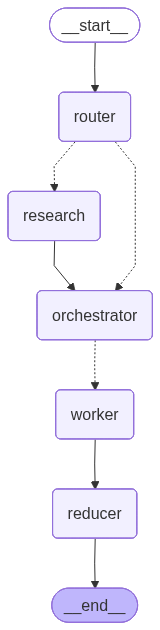

In [ ]:
app=g.compile()
app

In [ ]:
def run(topic: str):
  out= app.invoke(
      {
             "topic": topic,
            "mode": "",
            "needs_research": False, # Changed from requires_research to needs_research
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
      }
      )
  return out

In [ ]:
run("Write about Multi Agent systems in 2026")

/tmp/ipykernel_6095/4224620974.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool= TavilySearchResults(max_results=max_results, tavily_api_key=userdata.get("tavily"))


{'topic': 'Write about Multi Agent systems in 2026',
 'mode': 'hybrid',
 'needs_research': True,
 'queries': ['Advancements in Multi-Agent Systems 2026',
  'Applications of Multi-Agent Systems in robotics 2026',
  'Integration of AI with Multi-Agent Systems 2026',
  'Challenges in developing Multi-Agent Systems 2026',
  'New frameworks for Multi-Agent Systems 2026',
  'Role of blockchain in Multi-Agent Systems 2026',
  'Future of Multi-Agent Systems in healthcare 2026',
  'Applications of MAs in supply chain optimization 2026',
  'Security challenges in Multi-Agent Systems 2026',
  'Innovative tools for designing Multi-Agent Systems 2026'],
 'evidence': [EvidenceItem(title='Agent Design for 2026', url='https://agentdesignfor2026.com', published_at=None, snippet='The design of an agent for 2026 involves several key components, including tool schemas, structured JSON responses, validation, specialization, orchestration, error handling, security, monitoring, and ethical considerations. Ea